In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency


In [2]:
!apt-get install -y fonts-nanum -q > /dev/null

import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [3]:
df=pd.read_csv('/content/FDA_adverse_events_final.csv')

In [4]:
def U(s): return '' if pd.isna(s) else str(s).upper()

def classify_derm(row):
    sd = U(row['suspect_drug']); bn = U(row['brand_name']); t = sd + ' ' + bn
    if 'MINOXIDIL' in t or 'ROGAINE' in t:
        return 'A. 탈모치료제(Minoxidil)'
    if 'HYDROCORTISONE' in t or 'CORTISOL' in t:
        return 'B. 스테로이드 항염/항소양크림(Hydrocortisone)'
    if 'TERBINAFINE' in t or 'LAMISIL' in t:
        return 'C. 항진균제-경구/스프레이(Terbinafine)'
    if 'DOCOSANOL' in t or ('LIDOCAINE' in t and 'GLYCERIN' in t):
        return 'D. 헤르페스/국소마취(Docosanol+Lidocaine)'
    if 'CLOTRIMAZOLE' in t or 'MICONAZOLE' in t or 'NIZORAL' in t or 'LOTRIMIN' in t:
        return 'E. 항진균크림(Clotrimazole/Miconazole)'
    if 'TOLNAFTATE' in t:
        return 'F. 항진균제(Tolnaftate)'
    if 'SALICYLIC ACID' in t:
        return 'G. 각질제거/사마귀치료(Salicylic Acid)'
    return 'H. 기타'

D = df[df['WHO_ATC']=='D'].copy()
D['category'] = D.apply(classify_derm, axis=1)
M = D[D['category']=='A. 탈모치료제(Minoxidil)'].copy()

print(f"Minoxidil: {len(M)}건 / D그룹 전체 {len(D)}건 / 전체데이터 {len(df)}건")

Minoxidil: 292건 / D그룹 전체 641건 / 전체데이터 18273건


In [5]:

def dist_table(d, col, label):
    cnt = d[col].value_counts()
    pct = (cnt / len(d) * 100).round(1)
    return pd.DataFrame({f'{label}_건수': cnt, f'{label}_비율(%)': pct})

# 성별
sex_m = dist_table(M, 'patient_sex', 'Minoxidil')
sex_d = dist_table(D, 'patient_sex', 'D그룹전체')
sex_all = dist_table(df, 'patient_sex', '전체데이터')
sex_compare = sex_m.join(sex_d, how='outer').join(sex_all, how='outer').fillna(0)

tab_sex = pd.crosstab(pd.concat([M['patient_sex'], df['patient_sex']]),
                       ['M']*len(M) + ['전체']*len(df))
_, p_sex, _, _ = chi2_contingency(tab_sex)

# 연령대
age_order = ['Infant(0-2)','Child(3-12)','Teen(13-18)','Adult(19-40)',
             'Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)','Unknown']  # 전체 연령대로 복원

age_m = dist_table(M, 'age_group', 'Minoxidil')
age_d = dist_table(D, 'age_group', 'D그룹전체')
age_all = dist_table(df, 'age_group', '전체데이터')
age_compare = age_m.join(age_d, how='outer').join(age_all, how='outer').fillna(0)
age_compare = age_compare.reindex(age_order).fillna(0)

M_age = M[M['age_group'] != 'Unknown']
df_age = df[df['age_group'] != 'Unknown']
tab_age = pd.crosstab(pd.concat([M_age['age_group'], df_age['age_group']]),
                       ['M']*len(M_age) + ['전체']*len(df_age))
_, p_age, _, _ = chi2_contingency(tab_age)

# 복약수
dc_order = ['Single','2-3 Drugs','4-5 Drugs','Polypharmacy(6+)']
dc_m = dist_table(M, 'drug_count_category', 'Minoxidil')
dc_d = dist_table(D, 'drug_count_category', 'D그룹전체')
dc_all = dist_table(df, 'drug_count_category', '전체데이터')
dc_compare = dc_m.join(dc_d, how='outer').join(dc_all, how='outer').fillna(0).reindex(dc_order)

tab_dc = pd.crosstab(pd.concat([M['drug_count_category'], df['drug_count_category']]),
                      ['M']*len(M) + ['전체']*len(df))
_, p_dc, _, _ = chi2_contingency(tab_dc)

print('=== 성별 ===\n', sex_compare[['Minoxidil_비율(%)','D그룹전체_비율(%)','전체데이터_비율(%)']], f'\np(Minoxidil vs 전체)={p_sex:.4f}\n')
print('=== 연령대 ===\n', age_compare[['Minoxidil_비율(%)','D그룹전체_비율(%)','전체데이터_비율(%)']], f'\np(Minoxidil vs 전체)={p_age:.4f}\n')
print('=== 복약수 ===\n', dc_compare[['Minoxidil_비율(%)','D그룹전체_비율(%)','전체데이터_비율(%)']], f'\np(Minoxidil vs 전체)={p_dc:.4f}')

=== 성별 ===
              Minoxidil_비율(%)  D그룹전체_비율(%)  전체데이터_비율(%)
patient_sex                                           
Female                  63.4         58.7         49.7
Male                    33.2         34.9         35.6
Unknown                  3.4          6.4         14.6 
p(Minoxidil vs 전체)=0.0000

=== 연령대 ===
                     Minoxidil_비율(%)  D그룹전체_비율(%)  전체데이터_비율(%)
age_group                                                    
Infant(0-2)                     0.0          0.6          0.9
Child(3-12)                     0.0          2.3          1.4
Teen(13-18)                     0.0          2.2          1.7
Adult(19-40)                   12.0         14.0          8.9
Middle-Aged(41-65)             22.6         27.9         32.2
Senior(66-80)                  17.8         18.3         20.0
Elderly(81+)                    3.1          2.8          6.1
Unknown                        44.5         31.8         28.8 
p(Minoxidil vs 전체)=0.0008

=== 복약수 ===
            

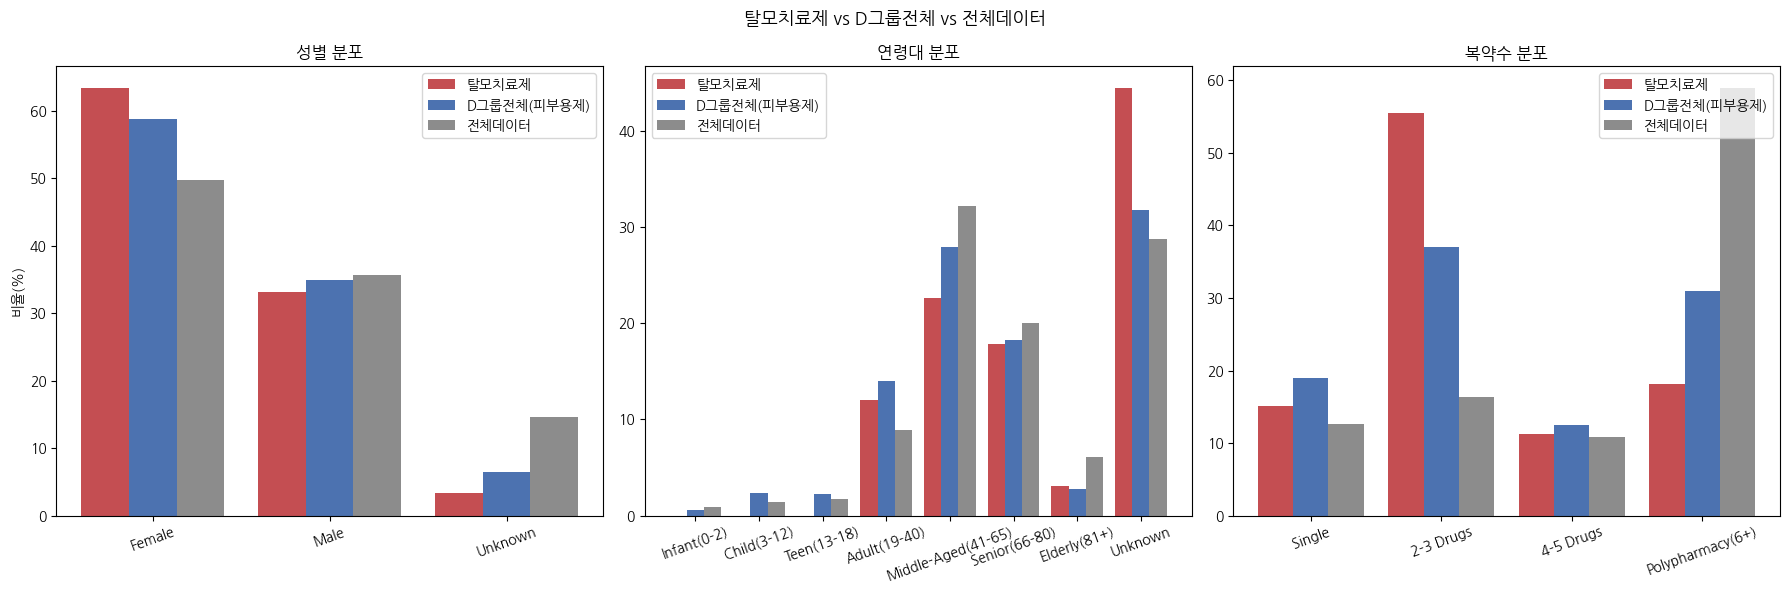

In [6]:
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
w = 0.27

def plot_3way(ax, compare_df, title):
    x = range(len(compare_df))
    ax.bar([i-w for i in x], compare_df['Minoxidil_비율(%)'], width=w, label='탈모치료제', color='#C44E52')
    ax.bar([i for i in x], compare_df['D그룹전체_비율(%)'], width=w, label='D그룹전체(피부용제)', color='#4C72B0')
    ax.bar([i+w for i in x], compare_df['전체데이터_비율(%)'], width=w, label='전체데이터', color='#8C8C8C')
    ax.set_xticks(x); ax.set_xticklabels(compare_df.index, rotation=20)
    ax.set_title(title)
    ax.legend()

plot_3way(axes[0], sex_compare, f'성별 분포')
axes[0].set_ylabel('비율(%)')
plot_3way(axes[1], age_compare, f'연령대 분포')
plot_3way(axes[2], dc_compare, f'복약수 분포')

plt.suptitle('탈모치료제 vs D그룹전체 vs 전체데이터', fontsize=13)
plt.tight_layout()
plt.show()

Serious  Minoxidil=11.6% D전체=45.6% 전체=85.6%  p(vs D)=0.0000  p(vs 전체)=0.0000
사망       Minoxidil=0.0% D전체=3.0% 전체=14.4%  p(vs D)=0.0065  p(vs 전체)=0.0000
입원       Minoxidil=2.7% D전체=20.6% 전체=34.4%  p(vs D)=0.0000  p(vs 전체)=0.0000
생명위협     Minoxidil=1.7% D전체=4.1% 전체=5.5%  p(vs D)=0.0979  p(vs 전체)=0.0065
장애       Minoxidil=1.7% D전체=3.6% 전체=3.1%  p(vs D)=0.1769  p(vs 전체)=0.2210


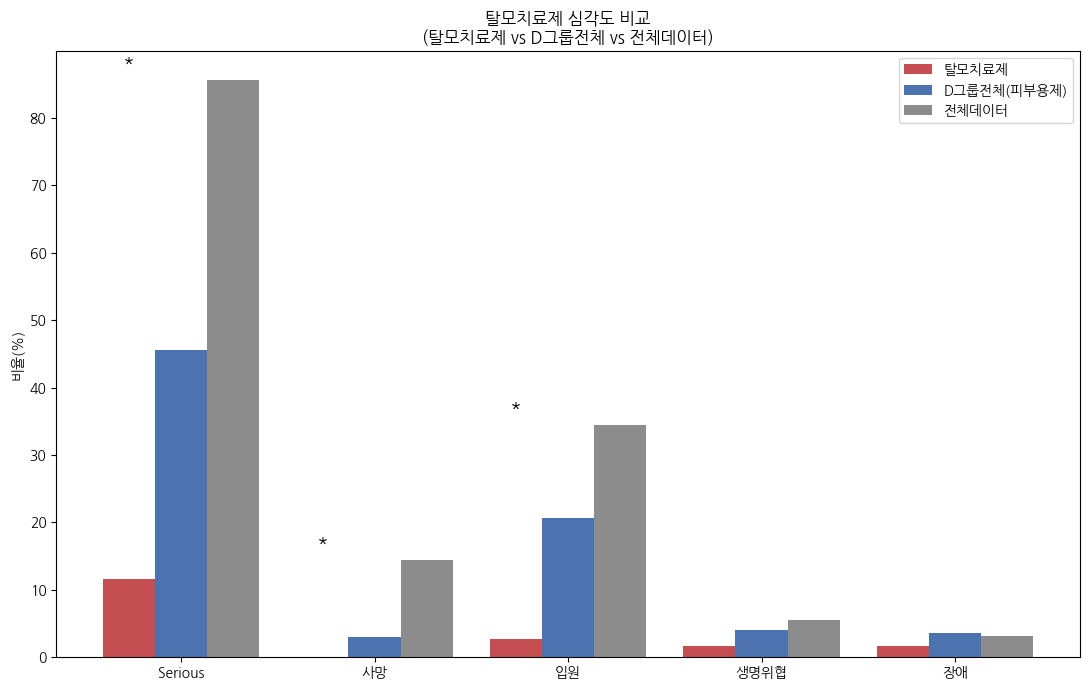

In [7]:

sev_cols = ['serious','is_fatal','is_hospitalized','is_life_threat','is_disabling']
sev_labels = {'serious':'Serious','is_fatal':'사망','is_hospitalized':'입원','is_life_threat':'생명위협','is_disabling':'장애'}

def sev_rate(d, col):
    v = d[col].astype(str)
    pos = 'Yes' if col == 'serious' else 'True'
    return round((v == pos).mean() * 100, 1)

minox_rates, d_rates, all_rates = [], [], []
p_vs_d, p_vs_all = [], []

for col in sev_cols:
    m_r, d_r, a_r = sev_rate(M, col), sev_rate(D, col), sev_rate(df, col)
    minox_rates.append(m_r); d_rates.append(d_r); all_rates.append(a_r)

    v_m = M[col].astype(str); v_d = D[col].astype(str); v_all = df[col].astype(str)
    pos = 'Yes' if col == 'serious' else 'True'
    neg = 'No' if col == 'serious' else 'False'

    tab_d = [[(v_m==pos).sum(), (v_m==neg).sum()], [(v_d==pos).sum(), (v_d==neg).sum()]]
    _, pd_, _, _ = chi2_contingency(tab_d)
    p_vs_d.append(pd_)

    tab_all = [[(v_m==pos).sum(), (v_m==neg).sum()], [(v_all==pos).sum(), (v_all==neg).sum()]]
    _, pa_, _, _ = chi2_contingency(tab_all)
    p_vs_all.append(pa_)

    print(f'{sev_labels[col]:8s} Minoxidil={m_r}% D전체={d_r}% 전체={a_r}%  p(vs D)={pd_:.4f}  p(vs 전체)={pa_:.4f}')

plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(11, 7))
x = range(len(sev_cols))
w = 0.27
b1 = ax.bar([i-w for i in x], minox_rates, width=w, label='탈모치료제', color='#C44E52')
b2 = ax.bar([i for i in x], d_rates, width=w, label='D그룹전체(피부용제)', color='#4C72B0')
b3 = ax.bar([i+w for i in x], all_rates, width=w, label='전체데이터', color='#8C8C8C')

# 유의성 표시 (vs D그룹전체 기준, * p<0.05)
for i, (bar, p) in enumerate(zip(b1, p_vs_d)):
    if p < 0.05:
        ax.text(bar.get_x()+bar.get_width()/2, max(minox_rates[i], d_rates[i], all_rates[i])+2, '*', ha='center', fontsize=14, color='black')

ax.set_xticks(x)
ax.set_xticklabels([sev_labels[c] for c in sev_cols])
ax.set_ylabel('비율(%)')
ax.set_title('탈모치료제 심각도 비교\n(탈모치료제 vs D그룹전체 vs 전체데이터)')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# 1. D그룹, Minoxidil 재생성
def U(s): return '' if pd.isna(s) else str(s).upper()

def classify_derm(row):
    sd = U(row['suspect_drug']); bn = U(row['brand_name']); t = sd + ' ' + bn
    if 'MINOXIDIL' in t or 'ROGAINE' in t: return 'A. 탈모치료제(Minoxidil)'
    if 'HYDROCORTISONE' in t or 'CORTISOL' in t: return 'B. 스테로이드 항염/항소양크림(Hydrocortisone)'
    if 'TERBINAFINE' in t or 'LAMISIL' in t: return 'C. 항진균제-경구/스프레이(Terbinafine)'
    if 'DOCOSANOL' in t or ('LIDOCAINE' in t and 'GLYCERIN' in t): return 'D. 헤르페스/국소마취(Docosanol+Lidocaine)'
    if 'CLOTRIMAZOLE' in t or 'MICONAZOLE' in t or 'NIZORAL' in t or 'LOTRIMIN' in t: return 'E. 항진균크림(Clotrimazole/Miconazole)'
    if 'TOLNAFTATE' in t: return 'F. 항진균제(Tolnaftate)'
    if 'SALICYLIC ACID' in t: return 'G. 각질제거/사마귀치료(Salicylic Acid)'
    return 'H. 기타'

D = df[df['WHO_ATC']=='D'].copy()
D['category'] = D.apply(classify_derm, axis=1)
M = D[D['category']=='A. 탈모치료제(Minoxidil)'].copy()

# 2. reaction_group 컬럼 생성 (여기가 빠져있었던 부분)
misuse_kw = ['PRODUCT USE ISSUE','OFF LABEL USE','INTENTIONAL PRODUCT MISUSE','PRODUCT ADMINISTERED AT INAPPROPRIATE SITE',
             'INAPPROPRIATE SCHEDULE','PRODUCT USE IN UNAPPROVED INDICATION','PRODUCT QUALITY ISSUE','OVERDOSE',
             'WRONG PATIENT','PRODUCT FORMULATION ISSUE','WRONG TECHNIQUE','INCORRECT DOSE','EXPIRED PRODUCT',
             'PRODUCT PRESCRIBING ERROR','MEDICATION ERROR','INEFFECTIVE FOR UNAPPROVED','INCORRECT PRODUCT ADMINISTRATION DURATION',
             'PRODUCT DOSE OMISSION','CONTRAINDICATED PRODUCT','PRODUCT USE COMPLAINT','EXTRA DOSE','INCORRECT ROUTE',
             'DRUG ADMINISTERED AT INAPPROPRIATE SITE']
hair_kw = ['DRUG INEFFECTIVE','ALOPECIA','HAIR TEXTURE ABNORMAL','HAIR GROWTH ABNORMAL','HAIR COLOUR CHANGES',
           'CONDITION AGGRAVATED','DRUG EFFECT INCOMPLETE','THERAPEUTIC RESPONSE','DRUG EFFECT DECREASED',
           'HAIR DISORDER','HYPERTRICHOSIS','TRICHORRHEXIS','DANDRUFF','THERAPEUTIC PRODUCT EFFECT']
skin_kw = ['PRURITUS','ERYTHEMA','SKIN EXFOLIATION','PAIN OF SKIN','APPLICATION SITE RASH','SKIN BURNING',
           'SEBORRHOEA','DRY SKIN','APPLICATION SITE PRURITUS','SKIN LESION','SKIN IRRITATION','NODULE',
           'APPLICATION SITE DISCOMFORT','APPLICATION SITE EXFOLIATION','SKIN WRINKLING','SKIN TIGHTNESS',
           'SKIN DISCOLOURATION','APPLICATION SITE PAIN','PERIORBITAL SWELLING','APPLICATION SITE NODULE',
           'APPLICATION SITE VESICLES','DERMATITIS','BURNING SENSATION','ACNE','PSORIASIS','SKIN DISORDER',
           'PRODUCT ODOUR']
cardio_kw = ['PERICARDIAL EFFUSION','CHEST PAIN','FLUSHING','MYOCARDIAL INFARCTION','TACHYCARDIA','HYPOTENSION',
             'PERIPHERAL SWELLING','TREMOR']
neuro_kw = ['HEADACHE','DEPRESSION','DIZZINESS','EMOTIONAL DISORDER','EAR DISCOMFORT']

def classify_reaction(reaction):
    t = str(reaction).upper()
    if any(k in t for k in misuse_kw): return '오남용/사용행태'
    if any(k in t for k in hair_kw): return '치료효과미흡/모발반응'
    if any(k in t for k in cardio_kw): return '심혈관계'
    if any(k in t for k in neuro_kw): return '신경/정신계'
    if any(k in t for k in skin_kw): return '국소피부반응'
    return '미분류'

M['reaction_group'] = M['primary_reaction'].apply(classify_reaction)
D['reaction_group'] = D['primary_reaction'].apply(classify_reaction)

cats_order = ['오남용/사용행태','치료효과미흡/모발반응','국소피부반응','심혈관계','신경/정신계','미분류']

def pct_table(d):
    cnt = d['reaction_group'].value_counts()
    return (cnt / len(d) * 100).round(1).reindex(cats_order).fillna(0)

reaction_compare_2way = pd.DataFrame({
    'Minoxidil(%)': pct_table(M),
    'D그룹전체(%)': pct_table(D),
})
print(reaction_compare_2way)

                Minoxidil(%)  D그룹전체(%)
reaction_group                        
오남용/사용행태                38.0      20.0
치료효과미흡/모발반응             32.2      17.8
국소피부반응                  17.1       9.5
심혈관계                     3.4       1.9
신경/정신계                   2.1       1.4
미분류                      7.2      49.5


Minoxidil: 292건 / D그룹나머지: 349건
                Minoxidil(%)  D그룹나머지(%)
reaction_group                         
오남용/사용행태                41.0       32.1
치료효과미흡/모발반응             34.7       37.7
국소피부반응                  18.5       20.8
심혈관계                     3.7        3.8
신경/정신계                   2.2        5.7

분류된 건수: Minoxidil 271/292, D그룹나머지 53/349


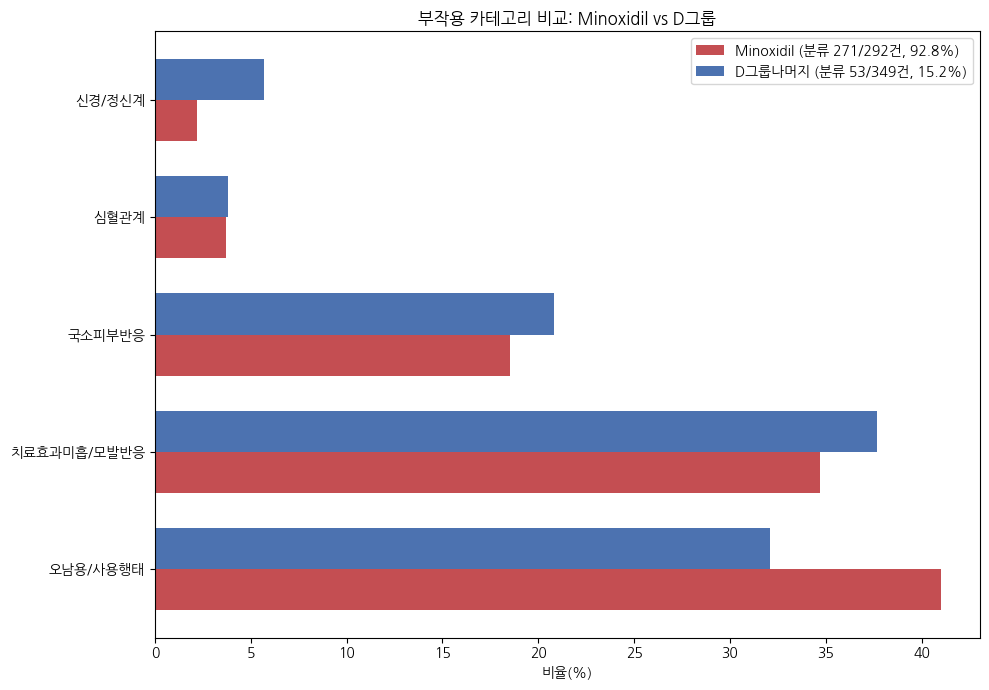

In [9]:
#  D그룹 전체 재분류 (Minoxidil 포함 여부 확인용)
def classify_derm(row):
    sd = U(row['suspect_drug']); bn = U(row['brand_name']); t = sd + ' ' + bn
    if 'MINOXIDIL' in t or 'ROGAINE' in t: return 'A. 탈모치료제(Minoxidil)'
    if 'HYDROCORTISONE' in t or 'CORTISOL' in t: return 'B. 스테로이드 항염/항소양크림(Hydrocortisone)'
    if 'TERBINAFINE' in t or 'LAMISIL' in t: return 'C. 항진균제-경구/스프레이(Terbinafine)'
    if 'DOCOSANOL' in t or ('LIDOCAINE' in t and 'GLYCERIN' in t): return 'D. 헤르페스/국소마취(Docosanol+Lidocaine)'
    if 'CLOTRIMAZOLE' in t or 'MICONAZOLE' in t or 'NIZORAL' in t or 'LOTRIMIN' in t: return 'E. 항진균크림(Clotrimazole/Miconazole)'
    if 'TOLNAFTATE' in t: return 'F. 항진균제(Tolnaftate)'
    if 'SALICYLIC ACID' in t: return 'G. 각질제거/사마귀치료(Salicylic Acid)'
    return 'H. 기타'

D = df[df['WHO_ATC']=='D'].copy()
D['category'] = D.apply(classify_derm, axis=1)
M = D[D['category']=='A. 탈모치료제(Minoxidil)'].copy()
D_rest = D[D['category'] != 'A. 탈모치료제(Minoxidil)'].copy()   # ← Minoxidil 제외한 나머지

print(f"Minoxidil: {len(M)}건 / D그룹나머지: {len(D_rest)}건")

# reaction_group 분류 함수 (기존과 동일)
misuse_kw = ['PRODUCT USE ISSUE','OFF LABEL USE','INTENTIONAL PRODUCT MISUSE','PRODUCT ADMINISTERED AT INAPPROPRIATE SITE',
             'INAPPROPRIATE SCHEDULE','PRODUCT USE IN UNAPPROVED INDICATION','PRODUCT QUALITY ISSUE','OVERDOSE',
             'WRONG PATIENT','PRODUCT FORMULATION ISSUE','WRONG TECHNIQUE','INCORRECT DOSE','EXPIRED PRODUCT',
             'PRODUCT PRESCRIBING ERROR','MEDICATION ERROR','INEFFECTIVE FOR UNAPPROVED','INCORRECT PRODUCT ADMINISTRATION DURATION',
             'PRODUCT DOSE OMISSION','CONTRAINDICATED PRODUCT','PRODUCT USE COMPLAINT','EXTRA DOSE','INCORRECT ROUTE',
             'DRUG ADMINISTERED AT INAPPROPRIATE SITE']
hair_kw = ['DRUG INEFFECTIVE','ALOPECIA','HAIR TEXTURE ABNORMAL','HAIR GROWTH ABNORMAL','HAIR COLOUR CHANGES',
           'CONDITION AGGRAVATED','DRUG EFFECT INCOMPLETE','THERAPEUTIC RESPONSE','DRUG EFFECT DECREASED',
           'HAIR DISORDER','HYPERTRICHOSIS','TRICHORRHEXIS','DANDRUFF','THERAPEUTIC PRODUCT EFFECT']
skin_kw = ['PRURITUS','ERYTHEMA','SKIN EXFOLIATION','PAIN OF SKIN','APPLICATION SITE RASH','SKIN BURNING',
           'SEBORRHOEA','DRY SKIN','APPLICATION SITE PRURITUS','SKIN LESION','SKIN IRRITATION','NODULE',
           'APPLICATION SITE DISCOMFORT','APPLICATION SITE EXFOLIATION','SKIN WRINKLING','SKIN TIGHTNESS',
           'SKIN DISCOLOURATION','APPLICATION SITE PAIN','PERIORBITAL SWELLING','APPLICATION SITE NODULE',
           'APPLICATION SITE VESICLES','DERMATITIS','BURNING SENSATION','ACNE','PSORIASIS','SKIN DISORDER',
           'PRODUCT ODOUR']
cardio_kw = ['PERICARDIAL EFFUSION','CHEST PAIN','FLUSHING','MYOCARDIAL INFARCTION','TACHYCARDIA','HYPOTENSION',
             'PERIPHERAL SWELLING','TREMOR']
neuro_kw = ['HEADACHE','DEPRESSION','DIZZINESS','EMOTIONAL DISORDER','EAR DISCOMFORT']

def classify_reaction(reaction):
    t = str(reaction).upper()
    if any(k in t for k in misuse_kw): return '오남용/사용행태'
    if any(k in t for k in hair_kw): return '치료효과미흡/모발반응'
    if any(k in t for k in cardio_kw): return '심혈관계'
    if any(k in t for k in neuro_kw): return '신경/정신계'
    if any(k in t for k in skin_kw): return '국소피부반응'
    return '미분류'

M['reaction_group'] = M['primary_reaction'].apply(classify_reaction)
D_rest['reaction_group'] = D_rest['primary_reaction'].apply(classify_reaction)

#  미분류 제외 비율 계산
cats_order = ['오남용/사용행태','치료효과미흡/모발반응','국소피부반응','심혈관계','신경/정신계']

def pct_table_excl(d):
    d2 = d[d['reaction_group'] != '미분류']
    cnt = d2['reaction_group'].value_counts()
    pct = (cnt / len(d2) * 100).round(1)
    return pct.reindex(cats_order).fillna(0), len(d2)

m_pct, m_n = pct_table_excl(M)
rest_pct, rest_n = pct_table_excl(D_rest)

reaction_compare_rest = pd.DataFrame({'Minoxidil(%)': m_pct, 'D그룹나머지(%)': rest_pct})
print(reaction_compare_rest)
print(f"\n분류된 건수: Minoxidil {m_n}/{len(M)}, D그룹나머지 {rest_n}/{len(D_rest)}")

plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 7))
y = range(len(cats_order))
w = 0.35

ax.barh([i - w/2 for i in y], m_pct, height=w,
        label=f'Minoxidil (분류 {m_n}/{len(M)}건, {m_n/len(M)*100:.1f}%)', color='#C44E52')
ax.barh([i + w/2 for i in y], rest_pct, height=w,
        label=f'D그룹나머지 (분류 {rest_n}/{len(D_rest)}건, {rest_n/len(D_rest)*100:.1f}%)', color='#4C72B0')

ax.set_yticks(y)
ax.set_yticklabels(cats_order)
ax.set_xlabel('비율(%)')
ax.set_title('부작용 카테고리 비교: Minoxidil vs D그룹')
ax.legend()
plt.tight_layout()
plt.show()

               n  Serious   사망    입원  생명위협   장애
카테고리                                           
치료효과미흡/모발반응   94      1.1  0.0   0.0   0.0  1.1
오남용/사용행태     111      1.8  0.0   1.8   0.9  0.0
국소피부반응        50     12.0  0.0   0.0   0.0  6.0
신경/정신계         6     16.7  0.0   0.0   0.0  0.0
심혈관계          10     70.0  0.0  30.0   0.0  0.0


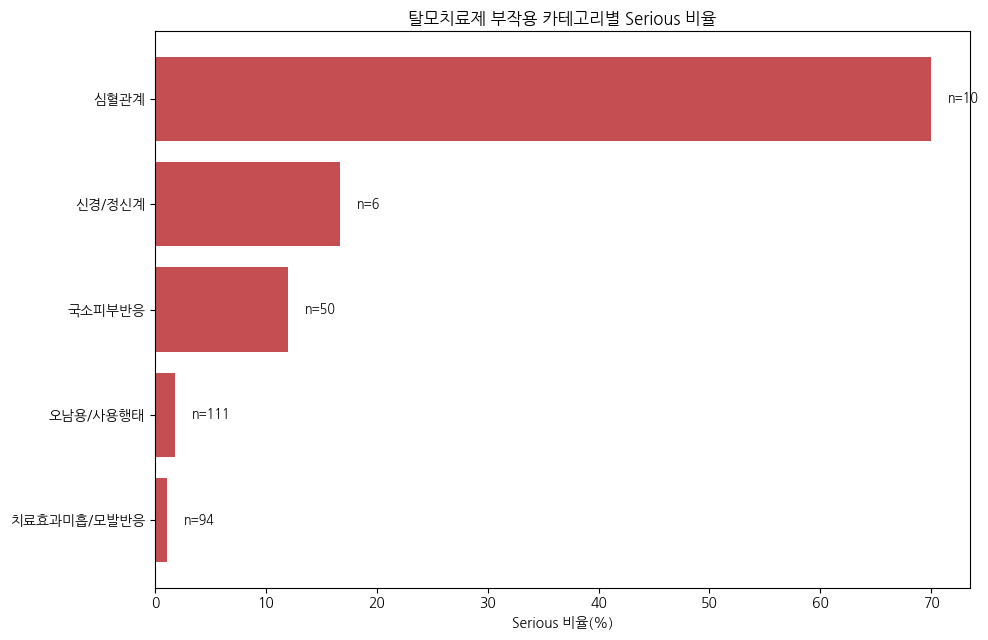

In [10]:
def sev_rate(d, col):
    v = d[col].astype(str)
    pos = 'Yes' if col == 'serious' else 'True'
    return round((v == pos).mean() * 100, 1)

sev_cols = ['serious','is_fatal','is_hospitalized','is_life_threat','is_disabling']
cats_order = ['치료효과미흡/모발반응','오남용/사용행태','국소피부반응','신경/정신계','심혈관계']

rows = []
for cat in cats_order:
    sub = M[M['reaction_group']==cat]
    n = len(sub)
    rates = [sev_rate(sub, c) for c in sev_cols]
    rows.append([cat, n] + rates)

severity_by_reaction_excl = pd.DataFrame(rows, columns=['카테고리','n','Serious','사망','입원','생명위협','장애']).set_index('카테고리')
print(severity_by_reaction_excl)

# 부작용 별 심각 정도
plt.rcParams['axes.unicode_minus'] = False

order = severity_by_reaction_excl.sort_values('Serious', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(order.index, order['Serious'], color='#C44E52')
for bar, n in zip(bars, order['n']):
    ax.text(bar.get_width()+1.5, bar.get_y()+bar.get_height()/2, f'n={n}', va='center', fontsize=9)
ax.set_xlabel('Serious 비율(%)')
ax.set_title('탈모치료제 부작용 카테고리별 Serious 비율')
plt.tight_layout()
plt.show()

                 n  recovered_n  recovery_pct
reaction_group                               
오남용/사용행태        46            6          13.0
치료효과미흡/모발반응     51            8          15.7
국소피부반응          43           13          30.2
심혈관계             8            5          62.5
신경/정신계           5            1          20.0


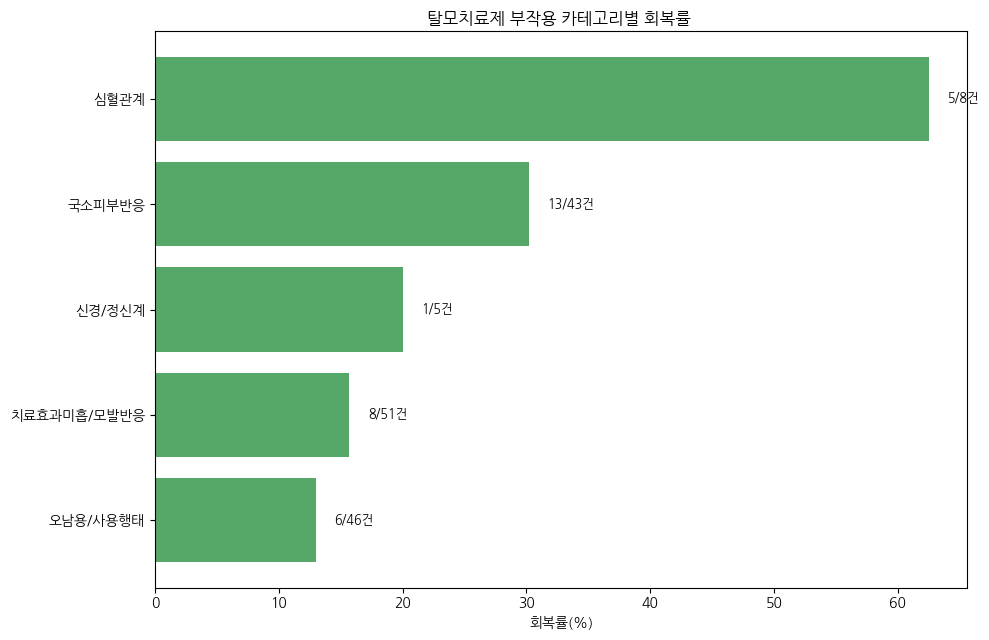

In [11]:
known = M[M['reaction_outcomes'] != 'Unknown'].copy()
cats_order = ['오남용/사용행태','치료효과미흡/모발반응','국소피부반응','심혈관계','신경/정신계']  # 미분류 제외

known_excl = known[known['reaction_group'] != '미분류']

recovery_excl = known_excl.groupby('reaction_group').agg(
    n=('patient_recovered','size'),
    recovered_n=('patient_recovered', lambda x: (x.astype(str)=='True').sum())
)
recovery_excl['recovery_pct'] = (recovery_excl['recovered_n']/recovery_excl['n']*100).round(1)
recovery_excl = recovery_excl.reindex(cats_order)
print(recovery_excl)

plt.rcParams['axes.unicode_minus'] = False

order = recovery_excl.sort_values('recovery_pct', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(order.index, order['recovery_pct'], color='#55A868')
for bar, row in zip(bars, order.itertuples()):
    ax.text(bar.get_width()+1.5, bar.get_y()+bar.get_height()/2, f'{row.recovered_n}/{row.n}건', va='center', fontsize=9)
ax.set_xlabel('회복률(%)')
ax.set_title(f'탈모치료제 부작용 카테고리별 회복률 ')
plt.tight_layout()
plt.show()

성별 회복률 검정: chi2=0.40, p=0.5249
             size  sum   pct
patient_sex                 
Female        114   24  21.1
Male           52   14  26.9
Unknown         3    2  66.7

연령대 회복률 검정: chi2=0.13, p=0.9884 (n=114)
                    size  sum   pct
age_group                          
Adult(19-40)          26    6  23.1
Middle-Aged(41-65)    46   11  23.9
Senior(66-80)         35    9  25.7
Elderly(81+)           7    2  28.6


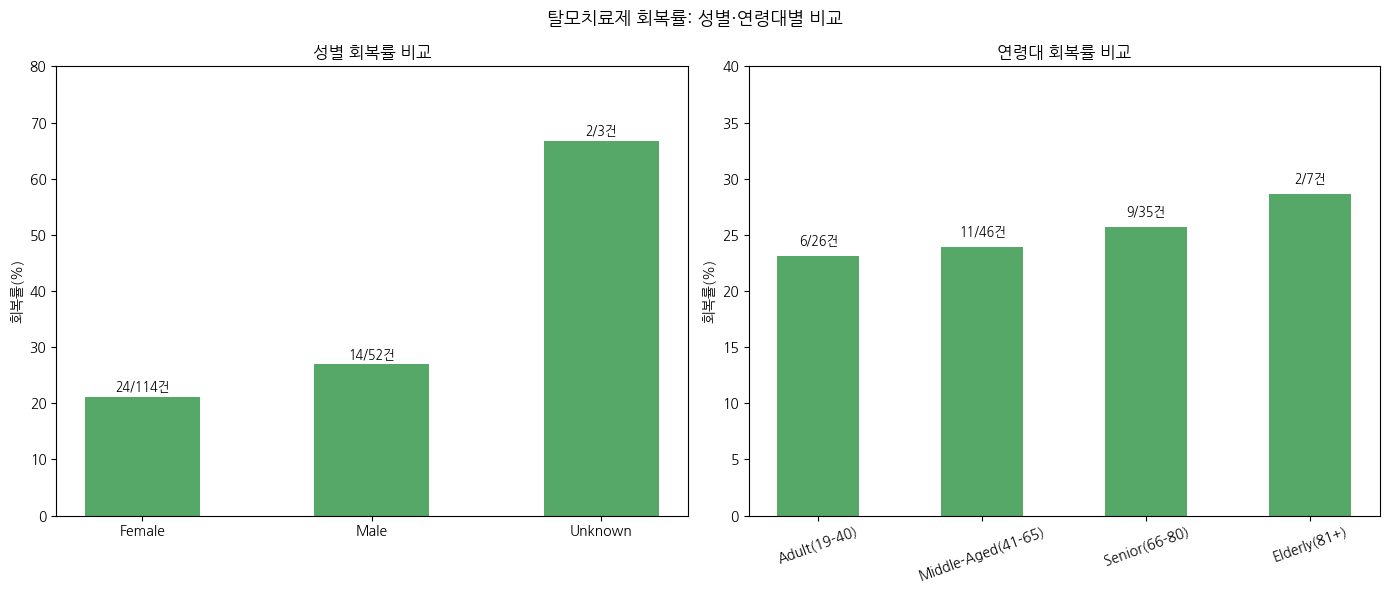

In [12]:
known = M[M['reaction_outcomes'] != 'Unknown'].copy()
known['is_recovered'] = known['patient_recovered'].astype(str) == 'True'

# 성별
sex_rec = known.groupby('patient_sex')['is_recovered'].agg(['size','sum'])
sex_rec['pct'] = (sex_rec['sum'] / sex_rec['size'] * 100).round(1)
sex_rec = sex_rec.reindex(['Female','Male','Unknown'])

tab_sex = pd.crosstab(known['patient_sex'], known['is_recovered']).loc[['Female','Male']]
chi2_sex, p_sex, dof, exp = chi2_contingency(tab_sex)
print(f"성별 회복률 검정: chi2={chi2_sex:.2f}, p={p_sex:.4f}")
print(sex_rec)
print()

#  연령대
known_age = known[known['age_group'] != 'Unknown']
age_order = ['Adult(19-40)','Middle-Aged(41-65)','Senior(66-80)','Elderly(81+)']
age_rec = known_age.groupby('age_group')['is_recovered'].agg(['size','sum'])
age_rec['pct'] = (age_rec['sum'] / age_rec['size'] * 100).round(1)
age_rec = age_rec.reindex(age_order)

tab_age = pd.crosstab(known_age['age_group'], known_age['is_recovered'])
chi2_age, p_age, dof, exp = chi2_contingency(tab_age)
print(f"연령대 회복률 검정: chi2={chi2_age:.2f}, p={p_age:.4f} (n={len(known_age)})")
print(age_rec)


plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars1 = axes[0].bar(sex_rec.index, sex_rec['pct'], color='#55A868', width=0.5)
for bar, row in zip(bars1, sex_rec.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{row.sum}/{row.size}건', ha='center', fontsize=9)
axes[0].set_ylabel('회복률(%)')
axes[0].set_title(f'성별 회복률 비교')
axes[0].set_ylim(0, 80)

bars2 = axes[1].bar(age_rec.index, age_rec['pct'], color='#55A868', width=0.5)
for bar, row in zip(bars2, age_rec.itertuples()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{row.sum}/{row.size}건', ha='center', fontsize=9)
axes[1].set_ylabel('회복률(%)')
axes[1].set_title(f'연령대 회복률 비교')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 40)

plt.suptitle('탈모치료제 회복률: 성별·연령대별 비교', fontsize=13)
plt.tight_layout()
plt.show()

primary_reaction
Pericardial effusion     3
Flushing                 1
Chest pain               1
Myocardial infarction    1
Tachycardia              1
Peripheral swelling      1
Tremor                   1
Hypotension              1
Name: count, dtype: int64


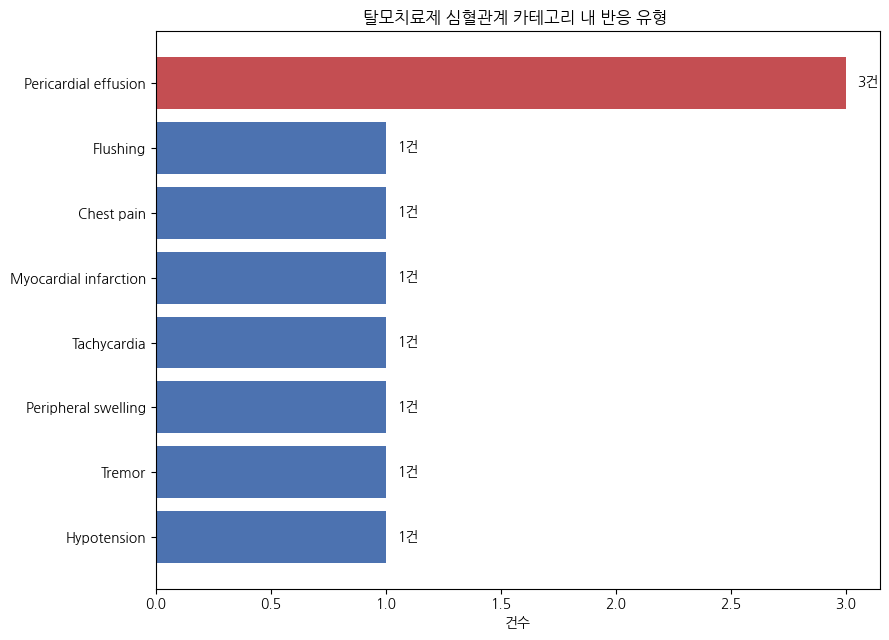

In [13]:
cardio_kw = ['PERICARDIAL EFFUSION','CHEST PAIN','FLUSHING','MYOCARDIAL INFARCTION','TACHYCARDIA',
             'HYPOTENSION','PERIPHERAL SWELLING','TREMOR']

def is_cardio(r):
    return any(k in str(r).upper() for k in cardio_kw)

M['is_cardio'] = M['primary_reaction'].apply(is_cardio)
cardio = M[M['is_cardio']]

reaction_counts = cardio['primary_reaction'].value_counts()
print(reaction_counts)

plt.rcParams['axes.unicode_minus'] = False

colors = ['#C44E52' if r=='Pericardial effusion' else '#4C72B0' for r in reaction_counts.index]

fig, ax = plt.subplots(figsize=(9, 6.5))
bars = ax.barh(reaction_counts.index[::-1], reaction_counts.values[::-1], color=colors[::-1])
for bar, c in zip(bars, reaction_counts.values[::-1]):
    ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2, f'{c}건', va='center', fontsize=10)
ax.set_xlabel('건수')
ax.set_title(f'탈모치료제 심혈관계 카테고리 내 반응 유형 ')
plt.tight_layout()
plt.show()

분류된 케이스: 53/111
misuse_sub
승인 외 부위/용도(오프라벨 추정)    35
용법·용량 오류(조급함 추정)       18
Name: count, dtype: int64


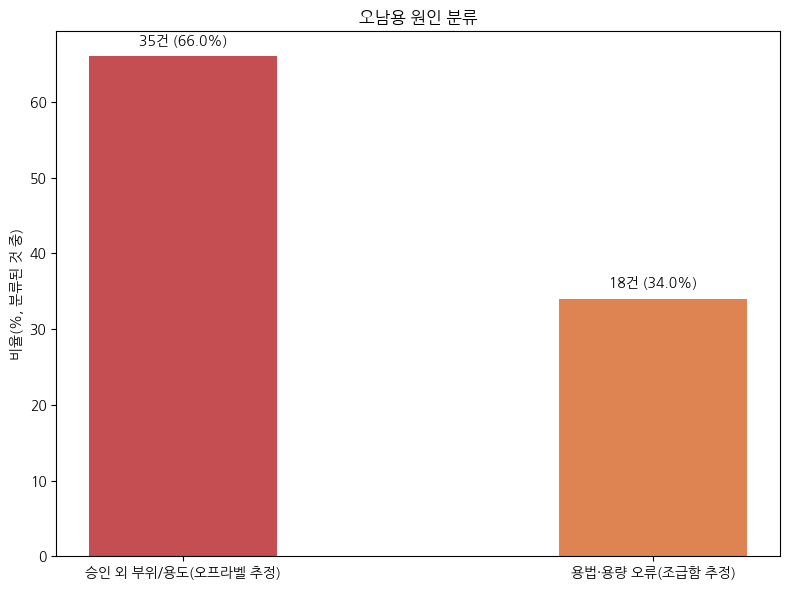

In [14]:
misuse_kw = ['PRODUCT USE ISSUE','OFF LABEL USE','INTENTIONAL PRODUCT MISUSE','PRODUCT ADMINISTERED AT INAPPROPRIATE SITE',
             'INAPPROPRIATE SCHEDULE','PRODUCT USE IN UNAPPROVED INDICATION','PRODUCT QUALITY ISSUE','OVERDOSE',
             'WRONG PATIENT','PRODUCT FORMULATION ISSUE','WRONG TECHNIQUE','INCORRECT DOSE','EXPIRED PRODUCT',
             'PRODUCT PRESCRIBING ERROR','MEDICATION ERROR','INEFFECTIVE FOR UNAPPROVED','INCORRECT PRODUCT ADMINISTRATION DURATION',
             'PRODUCT DOSE OMISSION','CONTRAINDICATED PRODUCT','PRODUCT USE COMPLAINT','EXTRA DOSE','INCORRECT ROUTE',
             'DRUG ADMINISTERED AT INAPPROPRIATE SITE']

def is_misuse(r):
    return any(k in str(r).upper() for k in misuse_kw)

M['is_misuse'] = M['primary_reaction'].apply(is_misuse)
misuse = M[M['is_misuse']].copy()

def misuse_subcategory(reaction):
    t = str(reaction).upper()
    site_kw = ['OFF LABEL USE', 'UNAPPROVED INDICATION', 'INAPPROPRIATE SITE']
    dose_kw = ['OVERDOSE', 'INCORRECT DOSE', 'INAPPROPRIATE SCHEDULE', 'EXTRA DOSE', 'DOSE OMISSION']
    if any(k in t for k in site_kw):
        return '승인 외 부위/용도(오프라벨 추정)'
    if any(k in t for k in dose_kw):
        return '용법·용량 오류(조급함 추정)'
    return '기타 행정/불명확'

misuse['misuse_sub'] = misuse['primary_reaction'].apply(misuse_subcategory)

sub_known = misuse[misuse['misuse_sub'] != '기타 행정/불명확']
sub_counts_known = sub_known['misuse_sub'].value_counts()
sub_pct_known = (sub_counts_known / len(sub_known) * 100).round(1)

print(f"분류된 케이스: {len(sub_known)}/{len(misuse)}")
print(sub_counts_known)

plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(sub_counts_known.index, sub_pct_known.values, color=['#C44E52','#DD8452'], width=0.4)
for bar, c, p in zip(bars, sub_counts_known.values, sub_pct_known.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5, f'{c}건 ({p:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('비율(%, 분류된 것 중)')
ax.set_title(f'오남용 원인 분류')
plt.tight_layout()
plt.show()